In [1]:
import pyvisa
import numpy as np
import time
import matplotlib.pyplot as plt

In [2]:
def test_oscilloscope(scope):
    """Quick test of oscilloscope functions"""
    print("\n  Testing Oscilloscope Commands:")

    try:
        # Query a channel
        result = scope.query('CH1:SCALE?')
        print(f"    CH1 Scale: {result.strip()}")
    except Exception as e:
        print(f"    CH1 query failed: {e}")

    try:
        # Query timebase
        result = scope.query('HOR:MAIN:SCALE?')
        print(f"    Timebase: {result.strip()}")
    except Exception as e:
        print(f"    Timebase query failed: {e}")

In [3]:
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL3::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'GPIB0::1::INSTR')


In [4]:
gpib_address = rm.list_resources()[3]  # 'GPIB0::1::INSTR'
print(f"Connecting to: {gpib_address}")

try:
    instr = rm.open_resource(gpib_address)
    instr.timeout = 5000  # 5 second timeout

    print("✓ Connected successfully!")

except Exception as e:
    print(f"✗ Connection failed: {e}")

test_oscilloscope(instr)

Connecting to: GPIB0::1::INSTR
✓ Connected successfully!

  Testing Oscilloscope Commands:
    CH1 Scale: 100.0000E-3
    Timebase: 400.0000E-9


In [7]:
class TDS6604Controller:
    def __init__(self, gpib_address='GPIB0::1::INSTR'):
        """Connect to scope"""
        self.rm = pyvisa.ResourceManager()
        self.scope = self.rm.open_resource(gpib_address)
        self.scope.timeout = 30000

        idn = self.scope.query('*IDN?')
        print(f"Connected to: {idn.strip()}")
        self.scope.write('*CLS')

    def get_current_settings(self, channel=1):
        """Display all current scope settings"""
        print(f"\n{'='*60}")
        print(f"CURRENT SCOPE SETTINGS")
        print(f"{'='*60}")

        print(f"\nChannel {channel}:")
        scale = self.scope.query(f'CH{channel}:SCALE?').strip()
        print(f"  Scale:     {scale} V/div")

        position = self.scope.query(f'CH{channel}:POSITION?').strip()
        print(f"  Position:  {position} div")

        coupling = self.scope.query(f'CH{channel}:COUPLING?').strip()
        print(f"  Coupling:  {coupling}")

        print(f"\nHorizontal:")
        h_scale = self.scope.query('HORIZONTAL:MAIN:SCALE?').strip()
        h_scale_float = float(h_scale)
        print(f"  Scale:         {h_scale} s/div ({h_scale_float*1e9:.3f} ns/div)")

        record_length = self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()
        print(f"  Record Length: {record_length} points")

        print(f"\nAcquisition:")
        acq_mode = self.scope.query('ACQUIRE:MODE?').strip()
        print(f"  Mode:       {acq_mode}")

        acq_state = self.scope.query('ACQUIRE:STATE?').strip()
        state_str = "Running" if acq_state == '1' else "Stopped"
        print(f"  State:      {acq_state} ({state_str})")

        print(f"\n{'='*60}\n")

    def setup_acquisition(self, channel=1, vertical_scale=0.5,
                         vertical_position=0, horizontal_scale=100e-9,
                         record_length=10000):
        """Setup oscilloscope for acquisition"""
        print(f"\n{'='*60}")
        print(f"CONFIGURING SCOPE")
        print(f"{'='*60}")

        print(f"\n1. Setting up Channel {channel}...")
        self.scope.write(f'SELECT:CH{channel} ON')
        self.scope.write(f'CH{channel}:SCALE {vertical_scale}')
        self.scope.write(f'CH{channel}:POSITION {vertical_position}')
        self.scope.write(f'CH{channel}:COUPLING DC')

        actual_scale = float(self.scope.query(f'CH{channel}:SCALE?').strip())
        print(f"   Scale: {actual_scale} V/div")
        print(f"   Channel configured")

        print(f"\n2. Setting up Timebase...")
        self.scope.write(f'HORIZONTAL:MAIN:SCALE {horizontal_scale}')

        actual_h_scale = float(self.scope.query('HORIZONTAL:MAIN:SCALE?').strip())
        print(f"   Requested: {horizontal_scale*1e9:.3f} ns/div")
        print(f"   Actual:    {actual_h_scale*1e9:.3f} ns/div")
        print(f"   Timebase set")

        print(f"\n3. Setting up Record Length...")
        self.scope.write(f'HORIZONTAL:RECORDLENGTH {record_length}')
        actual_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
        print(f"   Set to: {actual_length} points")

        print(f"\n4. Setting up Acquisition Mode...")
        self.scope.write('ACQUIRE:MODE SAMPLE')
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        print(f"   ✓ Single-sequence mode enabled")

        print(f"\n{'='*60}")
        print(f"SETUP COMPLETE")
        print(f"{'='*60}\n")

    def setup_trigger(self, source='CH1', level=1.65, edge='RISE', coupling='DC'):
        """Setup trigger with working verification"""
        print(f"\n{'='*60}")
        print(f"CONFIGURING TRIGGER")
        print(f"{'='*60}")

        print(f"\nSetting trigger parameters...")

        self.scope.write('TRIGGER:A:TYPE EDGE')
        self.scope.write(f'TRIGGER:A:EDGE:SOURCE {source}')
        self.scope.write(f'TRIGGER:A:EDGE:SLOPE {edge}')
        self.scope.write(f'TRIGGER:A:EDGE:COUPLING {coupling}')
        self.scope.write(f'TRIGGER:A:LEVEL {level}')
        self.scope.write('TRIGGER:A:MODE NORMAL')

        # Set trigger position at LEFT edge to capture full pattern
        self.scope.write('HORIZONTAL:MAIN:POSITION 0')

        # time.sleep(0.1)
        # print(f"\nVerifying settings...")
        # try:
        #     actual_source = self.scope.query('TRIGGER:A:EDGE:SOURCE?').strip()
        #     actual_slope = self.scope.query('TRIGGER:A:EDGE:SLOPE?').strip()
        #     actual_coupling = self.scope.query('TRIGGER:A:EDGE:COUPLING?').strip()
        #     actual_level = float(self.scope.query('TRIGGER:A:LEVEL?').strip())
        #     actual_mode = self.scope.query('TRIGGER:A:MODE?').strip()
        #
        #     print(f"  Source:   {actual_source}")
        #     print(f"  Slope:    {actual_slope}")
        #     print(f"  Coupling: {actual_coupling}")
        #     print(f"  Level:    {actual_level:.3f} V")
        #     print(f"  Mode:     {actual_mode}")
        #     print(f"\n  ✓ All settings verified")
        # except Exception as e:
        #     print(f"  Could not verify all settings: {e}")

        print(f"\n✓ Trigger configured")
        print(f"{'='*60}\n")


    def get_trigger_settings(self):
        """Query current trigger settings - uses verified working commands"""
        print(f"\n{'='*60}")
        print(f"CURRENT TRIGGER SETTINGS")
        print(f"{'='*60}\n")

        settings = {}

        try:
            settings['type'] = self.scope.query('TRIGGER:A:TYPE?').strip()
            print(f"  Type:              {settings['type']}")
        except:
            print(f"  Type:              (query failed)")

        try:
            settings['mode'] = self.scope.query('TRIGGER:A:MODE?').strip()
            print(f"  Mode:              {settings['mode']}")
        except:
            print(f"  Mode:              (query failed)")

        try:
            settings['source'] = self.scope.query('TRIGGER:A:EDGE:SOURCE?').strip()
            print(f"  Source:            {settings['source']}")
        except:
            print(f"  Source:            (query failed)")

        try:
            settings['slope'] = self.scope.query('TRIGGER:A:EDGE:SLOPE?').strip()
            print(f"  Slope:             {settings['slope']}")
        except:
            print(f"  Slope:             (query failed)")

        try:
            settings['coupling'] = self.scope.query('TRIGGER:A:EDGE:COUPLING?').strip()
            print(f"  Coupling:          {settings['coupling']}")
        except:
            print(f"  Coupling:          (query failed)")

        try:
            # This is the format that works!
            level = self.scope.query('TRIGGER:A:LEVEL?').strip()
            level_volts = float(level)
            settings['level'] = level_volts
            print(f"  Level:             {level_volts:.3f} V")
        except:
            print(f"  Level:             (query failed)")

        try:
            holdoff = self.scope.query('TRIGGER:A:HOLDOFF:TIME?').strip()
            settings['holdoff'] = float(holdoff)
            print(f"  Holdoff:           {holdoff} s ({float(holdoff)*1e9:.1f} ns)")
        except:
            print(f"  Holdoff:           (query failed)")

        try:
            h_pos = self.scope.query('HORIZONTAL:TRIGGER:POSITION?').strip()
            settings['h_position'] = float(h_pos)
            print(f"  Horiz Position:    {h_pos} %")
        except:
            print(f"  Horiz Position:    (query failed)")

        print(f"\n{'='*60}\n")

        return settings

    def setup_scope_for_pattern(self,
                            pulse_spacing=500e-9,
                            amplitude=3.3,
                            num_pulses=4):
        """
        Setup scope to capture the entire 4-pulse pattern AFTER trigger
        """
        print("="*60)
        print("CONFIGURING SCOPE")
        print("="*60 + "\n")

        # Calculate total pattern duration
        total_time = num_pulses * pulse_spacing

        # Add some margin to see after the last pulse
        display_time = total_time * 1.2  # 20% extra

        print(f"Pattern duration: {total_time*1e6:.2f} μs")
        print(f"Display window: {display_time*1e6:.2f} μs\n")

        # 1. Channel setup
        print("1. Channel setup...")
        self.scope.write('SELECT:CH1 ON')

        # Vertical scale
        v_scale = amplitude / 2
        self.scope.write(f'CH1:SCALE {v_scale}')
        self.scope.write('CH1:POSITION 0')
        self.scope.write('CH1:COUPLING DC')

        print(f"   Vertical: {v_scale} V/div (±{amplitude} V range)")

        # 2. Horizontal setup
        print("\n2. Horizontal setup...")

        # Timebase - spread pattern across screen
        h_scale = display_time / 10  # 10 divisions
        self.scope.write(f'HORIZONTAL:MAIN:SCALE {h_scale}')

        # KEY: Set trigger position to LEFT EDGE (0%)
        # This captures everything AFTER the trigger
        self.scope.write('HORIZONTAL:MAIN:POSITION 0')

        # Verify
        actual_h_scale = float(self.scope.query('HORIZONTAL:MAIN:SCALE?').strip())
        actual_h_pos = float(self.scope.query('HORIZONTAL:MAIN:POSITION?').strip())

        print(f"   Timebase: {actual_h_scale*1e9:.1f} ns/div")
        print(f"   Trigger position: {actual_h_pos}% (0=left edge)")
        print(f"   Total display: {actual_h_scale*10*1e9:.1f} ns")

        # 3. Record length
        print("\n3. Record length...")
        record_length = 10000
        self.scope.write(f'HORIZONTAL:RECORDLENGTH {record_length}')
        actual_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))

        sample_rate = actual_length / (actual_h_scale * 10)
        print(f"   Record length: {actual_length} points")
        print(f"   Sample rate: {sample_rate/1e9:.2f} GSa/s")
        print(f"   Time resolution: {1/sample_rate*1e9:.2f} ns/point")

        # 4. Acquisition mode
        print("\n4. Acquisition mode...")
        self.scope.write('ACQUIRE:MODE SAMPLE')
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        print("   Mode: Single sequence")

        print("\n✓ Scope configured to capture AFTER trigger")
        print("="*60 + "\n")

    def arm_acquisition(self):
        """Arm scope for single acquisition"""
        print(f"Arming scope (waiting for trigger)...")
        self.scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.1)  # Let scope arm

    def wait_for_acquisition(self, timeout=30):
        """Wait for acquisition to complete"""
        start_time = time.time()

        while True:
            state = int(self.scope.query('ACQUIRE:STATE?').strip())

            if state == 0:  # Stopped = acquisition complete
                print("✓ Acquisition complete!")
                return True

            if time.time() - start_time > timeout:
                print("✗ Acquisition timeout!")
                return False

            time.sleep(0.1)


    def capture_with_force_trigger(self):
        """Capture using software force trigger"""
        print("\n" + "="*70)
        print("CAPTURE WITH SOFTWARE FORCE TRIGGER")
        print("="*70)
        print("\nThis will capture whatever is on CH1 right now")
        print("(Even if just noise - that's fine for testing)\n")

        input("Press Enter to capture...")

        print("\nStarting acquisition...")

        # Stop any current acquisition
        self.scope.write('ACQUIRE:STATE OFF')
        time.sleep(0.1)

        # Start single sequence acquisition
        self.scope.write('ACQUIRE:STOPAFTER SEQUENCE')
        self.scope.write('ACQUIRE:STATE RUN')
        time.sleep(0.2)

        print("   Scope armed")

        # Force trigger via software
        print("   Forcing trigger via software...")
        self.scope.write('TRIGGER FORCE')

        # Wait for acquisition to complete
        time.sleep(0.5)

        # Check state
        max_wait = 5
        start = time.time()

        while time.time() - start < max_wait:
            state = int(self.scope.query('ACQUIRE:STATE?').strip())
            if state == 0:
                print("   ✓ Acquisition complete!")
                return True
            time.sleep(0.1)

        # Even if state isn't 0, data might be available
        print("Timeout waiting for state, but trying to get data anyway...")
        return True

    def get_waveform_data(self):
        """Retrieve waveform - FIXED VERSION"""
        print("\n" + "="*70)
        print("RETRIEVING WAVEFORM DATA")
        print("="*70 + "\n")

        try:
            # Configure data transfer
            print("1. Configuring data transfer...")
            self.scope.write('DATA:SOURCE CH1')
            self.scope.write('DATA:ENCDG RIBINARY')
            self.scope.write('DATA:WIDTH 2')
            self.scope.write('DATA:START 1')

            # Get record length
            record_length = int(float(self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()))
            self.scope.write(f'DATA:STOP {record_length}')
            print(f"   Record length: {record_length} points")

            # Get scaling parameters individually
            print("\n2. Getting scaling parameters...")

            x_incr = float(self.scope.query('WFMPRE:XINCR?').strip())
            x_zero = float(self.scope.query('WFMPRE:XZERO?').strip())
            y_mult = float(self.scope.query('WFMPRE:YMULT?').strip())
            y_zero = float(self.scope.query('WFMPRE:YZERO?').strip())
            y_off = float(self.scope.query('WFMPRE:YOFF?').strip())

            print(f"   X increment: {x_incr*1e9:.3f} ns/point")
            print(f"   Y multiplier: {y_mult*1e3:.3f} mV/count")

            # Request waveform
            print("\n3. Requesting waveform...")
            self.scope.write('CURVE?')

            print("4. Reading binary data...")
            raw_data = self.scope.read_raw()
            print(f"   Received {len(raw_data)} bytes")

            # Parse binary header: #<x><yyy><data>
            print("\n5. Parsing...")
            header_len = 2 + int(chr(raw_data[1]))
            byte_count = int(raw_data[2:header_len].decode('ascii'))
            data_bytes = raw_data[header_len:header_len + byte_count]

            print(f"   Data: {byte_count} bytes = {byte_count//2} points")

            # Convert to voltage
            print("\n6. Converting to voltage...")
            voltage_raw = np.frombuffer(data_bytes, dtype=np.dtype('>i2'))
            voltage = (voltage_raw - y_off) * y_mult + y_zero

            # Time array
            time_array = np.arange(len(voltage)) * x_incr + x_zero

            # Stats
            print(f"   ✓ {len(voltage)} points")
            print(f"\n7. Waveform stats:")
            print(f"   Time: {time_array[0]*1e6:.3f} to {time_array[-1]*1e6:.3f} μs")
            print(f"   Voltage: {voltage.min():.3f} to {voltage.max():.3f} V")
            print(f"   Mean: {voltage.mean():.3f} V")

            print("\n✓ Success!")
            print("="*70)

            return {
                'time': time_array,
                'voltage': voltage,
                'points': len(voltage)
            }

        except Exception as e:
            print(f"\n✗ Error: {e}")
            import traceback
            traceback.print_exc()
            return None

    def save_waveform(self, waveform, filename='waveform.csv'):
        """Save waveform to CSV with metadata header"""
        if waveform is None:
            return

        print(f"\nSaving to {filename}...")

        # Gather metadata from scope
        try:
            metadata = self._get_scope_metadata()
        except:
            metadata = {}

        # Create header with metadata
        header_lines = []
        header_lines.append("TDS 6604 Waveform Data")
        header_lines.append(f"Captured: {time.strftime('%Y-%m-%d %H:%M:%S')}")
        header_lines.append("")

        # Add metadata
        header_lines.append("SCOPE SETTINGS:")
        for key, value in metadata.items():
            header_lines.append(f"  {key}: {value}")

        header_lines.append("")
        header_lines.append("DATA:")
        header_lines.append("Time (s), Voltage (V)")

        # Combine into single header string
        header = '\n'.join(header_lines)

        # Save data
        data = np.column_stack((waveform['time'], waveform['voltage']))
        np.savetxt(filename, data, delimiter=',', header=header, comments='# ')

        print(f"✓ Saved {len(waveform['voltage'])} points with metadata")

    def _get_scope_metadata(self):
        """Gather scope configuration metadata"""
        metadata = {}

        try:
            # Identification
            metadata['Instrument'] = self.scope.query('*IDN?').strip()

            # Channel settings
            ch_scale = self.scope.query('CH1:SCALE?').strip()
            ch_position = self.scope.query('CH1:POSITION?').strip()
            ch_coupling = self.scope.query('CH1:COUPLING?').strip()
            ch_bw = self.scope.query('CH1:BANDWIDTH?').strip()

            metadata['CH1 Scale'] = f"{float(ch_scale)} V/div"
            metadata['CH1 Position'] = f"{float(ch_position)} div"
            metadata['CH1 Coupling'] = ch_coupling
            metadata['CH1 Bandwidth'] = ch_bw

            # Horizontal settings
            h_scale = self.scope.query('HORIZONTAL:MAIN:SCALE?').strip()
            h_position = self.scope.query('HORIZONTAL:MAIN:POSITION?').strip()
            record_length = self.scope.query('HORIZONTAL:RECORDLENGTH?').strip()

            metadata['Timebase'] = f"{float(h_scale)*1e9:.3f} ns/div"
            metadata['Horizontal Position'] = f"{float(h_position)} %"
            metadata['Record Length'] = f"{int(float(record_length))} points"

            # Acquisition settings
            acq_mode = self.scope.query('ACQUIRE:MODE?').strip()
            metadata['Acquisition Mode'] = acq_mode

            # Trigger settings
            try:
                trig_source = self.scope.query('TRIGGER:A:EDGE:SOURCE?').strip()
                trig_slope = self.scope.query('TRIGGER:A:EDGE:SLOPE?').strip()
                trig_level = self.scope.query('TRIGGER:A:LEVEL?').strip()
                trig_mode = self.scope.query('TRIGGER:A:MODE?').strip()

                metadata['Trigger Source'] = trig_source
                metadata['Trigger Slope'] = trig_slope
                metadata['Trigger Level'] = f"{float(trig_level)} V"
                metadata['Trigger Mode'] = trig_mode
            except:
                pass

            # Waveform parameters
            x_incr = self.scope.query('WFMPRE:XINCR?').strip()
            y_mult = self.scope.query('WFMPRE:YMULT?').strip()

            metadata['Sample Interval'] = f"{float(x_incr)*1e9:.6f} ns"
            metadata['Voltage Resolution'] = f"{float(y_mult)*1e6:.6f} uV/count"

        except Exception as e:
            print(f"  (Warning: Could not retrieve all metadata: {e})")

        return metadata

    def plot_waveform(self, waveform):
        """Plot waveform"""
        if waveform is None:
            return

        print("\n\Plotting...")

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.plot(waveform['time'] * 1e6, waveform['voltage'], 'b-', linewidth=0.5)
        ax.set_xlabel('Time (μs)')
        ax.set_ylabel('Voltage (V)')
        ax.set_title(f'TDS 6604 Waveform ({waveform["points"]} points)')
        ax.grid(True)

        plt.tight_layout()
        plt.savefig('waveform_plot.png', dpi=150)
        print("Saved to waveform_plot.png")

        try:
            plt.show()
        except:
            print("  (Display not available - saved to file)")


    def close(self):
        """Close connection"""
        self.scope.close()
        self.rm.close()
        print("\n Connection closed")


TDS 6604 COMPLETE ACQUISITION TEST
Connected to: TEKTRONIX,TDS6604,B010466,CF:91.1CT FV:2.5.3

CONFIGURING SCOPE

1. Setting up Channel 1...
   Scale: 0.1 V/div
   Channel configured

2. Setting up Timebase...
   Requested: 100.000 ns/div
   Actual:    200.000 ns/div
   Timebase set

3. Setting up Record Length...
   Set to: 25000 points

4. Setting up Acquisition Mode...
   ✓ Single-sequence mode enabled

SETUP COMPLETE


CONFIGURING TRIGGER

Setting trigger parameters...

✓ Trigger configured


CURRENT SCOPE SETTINGS

Channel 1:
  Scale:     100.0000E-3 V/div
  Position:  0.0000 div
  Coupling:  DC

Horizontal:
  Scale:         2.0000E-6 s/div (2000.000 ns/div)
  Record Length: 25000 points

Acquisition:
  Mode:       SAMPLE
  State:      0 (Stopped)



CURRENT TRIGGER SETTINGS

  Type:              EDGE
  Mode:              NORMAL
  Source:            CH1
  Slope:             RISE
  Coupling:          DC
  Level:             0.500 V
  Holdoff:           250.0000E-9 s (250.0 ns)
  H

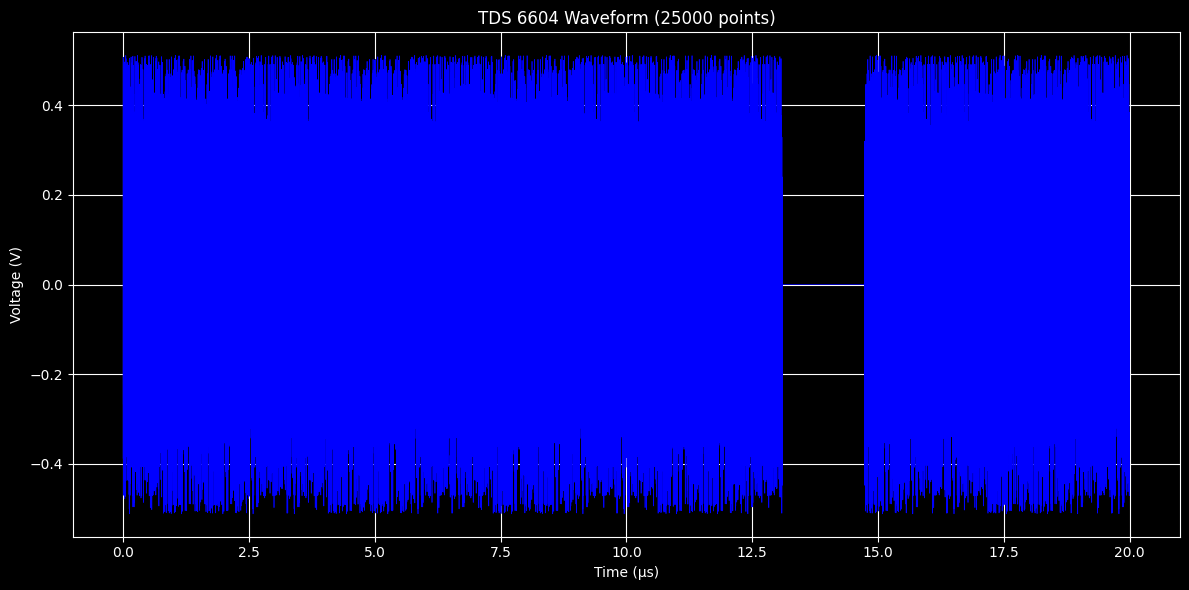


 Connection closed

Test complete


In [9]:
# ============================================================================
# COMPLETE TEST WITH ACQUISITION
# ============================================================================

if __name__ == '__main__':

    print("\n" + "="*60)
    print("TDS 6604 COMPLETE ACQUISITION TEST")
    print("="*60)

    scope = TDS6604Controller('GPIB0::2::INSTR')

    try:
        # Configure scope
        scope.setup_acquisition(
            channel=1,
            vertical_scale=0.1,        # 500 mV/div
            vertical_position=0,
            horizontal_scale=100e-9,   # 100 ns/div
            record_length=30000
        )

        # Setup trigger
        scope.setup_trigger(
            source='CH1',
            level=0.5,                 # Trigger at 500mV
            edge='RISE'
        )

        # Show settings
        scope.get_current_settings(channel=1)
        scope.get_trigger_settings()


        # scope.setup_scope_for_pattern(pulse_spacing=500e-9,
        #                         amplitude=2.,
        #                         num_pulses=4)
        # scope.arm_acquisition()

        print("\n>> ARMED")
        scope.capture_with_force_trigger()

        waveform = scope.get_waveform_data()
        if waveform:
            scope.save_waveform(waveform, 'captured_waveform.csv')

        scope.plot_waveform(waveform)

        # # Wait for trigger
        # if scope.wait_for_acquisition(timeout=30):
        #     # Get the data
        #     waveform = scope.get_waveform_data(channel=1)
        #
        #     # Save it
        #     scope.save_waveform(waveform, 'test_waveform.csv')
        #
        #     print("\n✓ SUCCESS! Waveform captured and saved.")
        #
        # else:
        #     print("\n✗ No trigger received within timeout")
        #     print("   Check:")
        #     print("   - Signal is connected to CH1")
        #     print("   - Signal crosses trigger level")
        #     print("   - Trigger level is appropriate")

    except KeyboardInterrupt:
        print("\n\nInterrupted by user")
    except Exception as e:
        print(f"\n✗ Error: {e}")
        import traceback
        traceback.print_exc()
    finally:
        scope.close()
        print("\n" + "="*60)
        print("Test complete")
        print("="*60)

In [12]:
scope = TDS6604Controller('GPIB0::2::INSTR')
scope.scope.write('DISPLAY:PERSISTENCE OFF')
scope.scope.write('ACQUIRE:STATE?')  # Should return 0 (stopped)
# scope.scope.write('HARDCOPY START')  # This forces a display refresh

Connected to: TEKTRONIX,TDS6604,B010466,CF:91.1CT FV:2.5.3


16